# Частотный анализ русского текста и построение облака слов

In [67]:
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

## Загрузка и отображение данных

In [68]:
import urllib3
import pandas as pd

# target_url = 'pushkin-metel.txt'
# http = urllib3.PoolManager()
# response = http.request('GET', target_url)
# data = response.data.decode('utf-8')
# # df = pd.DataFrame(data,columns=('text'))
# df = pd.read_fwf(data)
# df.sample(6)                   

In [69]:
f = open('/home/jovyan/work/ipynb_dock/data/belkin.txt', "r", encoding="utf-8")
text = f.read()

In [70]:
type(text)

str

In [71]:
len(text)

123835

In [72]:
text[:300]

' Александр Сергеевич Пушкин. Повести покойного Ивана Петровича Белкина\n\n Г-жа Простакова.\n То, мой батюшка, он еще сызмала к историям охотник.\n Скотинин.\n\n Митрофан по мне.\n Недоросль.\n\n\n ОТ ИЗДАТЕЛЯ\n\n Взявшись хлопотать об издании Повестей И. П. Белкина, предлагаемых ныне публике, мы желали к оным '

## Предварительная обработка текста

In [73]:
# перевод в единый регистр (например, нижний)
text = text.lower()

In [74]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [75]:
type(string.punctuation)

str

In [76]:
spec_chars = string.punctuation + '\n\xa0«»\t—…'

In [77]:
%%time
text = "".join([ch for ch in text if ch not in spec_chars])

CPU times: user 25.4 ms, sys: 1.2 ms, total: 26.6 ms
Wall time: 23.7 ms


In [78]:
import re
text = re.sub('\n', '', text)

In [79]:
def remove_chars_from_text(text, chars):
    return "".join([ch for ch in text if ch not in chars])

In [80]:
%%time
text = remove_chars_from_text(text, spec_chars)

CPU times: user 13.5 ms, sys: 9.2 ms, total: 22.7 ms
Wall time: 20.1 ms


In [81]:
%%time
text = remove_chars_from_text(text, string.digits)

CPU times: user 12.9 ms, sys: 11.3 ms, total: 24.2 ms
Wall time: 21.2 ms


## Токенизация текста

In [82]:
# !pip install nltk

In [83]:
import nltk
# nltk.download()

In [84]:
# import nltk
# nltk.download('punkt')

from nltk import word_tokenize
text_tokens = word_tokenize(text, language="russian")

In [85]:
print(type(text_tokens), len(text_tokens))
text_tokens[:10]

<class 'list'> 19032


['александр',
 'сергеевич',
 'пушкин',
 'повести',
 'покойного',
 'ивана',
 'петровича',
 'белкина',
 'гжа',
 'простакова']

In [86]:
import nltk
text = nltk.Text(text_tokens)
print(type(text))
text[:20]

<class 'nltk.text.Text'>


['александр',
 'сергеевич',
 'пушкин',
 'повести',
 'покойного',
 'ивана',
 'петровича',
 'белкина',
 'гжа',
 'простакова',
 'то',
 'мой',
 'батюшка',
 'он',
 'еще',
 'сызмала',
 'к',
 'историям',
 'охотник',
 'скотинин']

## Расчёт частоты встречаемости слов

In [87]:
%%time
from nltk.probability import FreqDist
fdist = FreqDist(text)
fdist

CPU times: user 13.4 ms, sys: 788 µs, total: 14.2 ms
Wall time: 12.9 ms


FreqDist({'и': 798, 'в': 516, 'не': 435, 'он': 272, 'с': 261, 'на': 259, 'что': 244, 'я': 240, 'его': 205, 'как': 128, ...})

In [88]:
fdist.most_common(5)

[('и', 798), ('в', 516), ('не', 435), ('он', 272), ('с', 261)]

<Axes: xlabel='Samples', ylabel='Counts'>

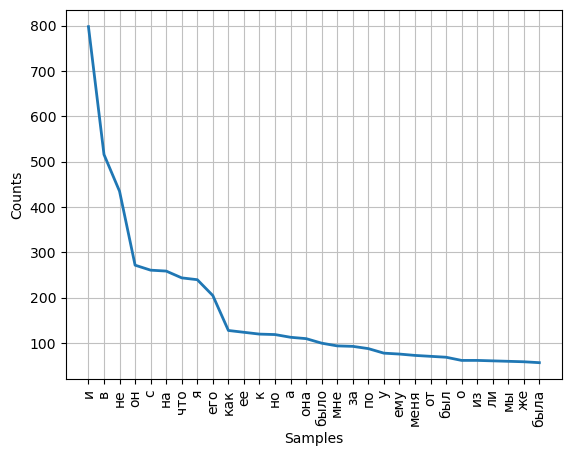

In [89]:
fdist.plot(30,cumulative=False)

## Удаление стоп-слов

In [90]:
from nltk.corpus import stopwords
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['и', 'в','это', 'с','это', 'нею','александр', 'лиза', 'сильвио', 'алексей', 'смотритель','всь','сказал','сказала','своей','своего',
 'сергеевич',
 'владимир',                         
 'пушкин',
 'повести',
 'покойного',
 'ивана',
 'петровича',
 'белкина',
 'гжа',
 'простакова',
 'то',
 'мой',
 'батюшка',
 'он',
 'еще',
 'сызмала',
 'к',
 'историям',
 'охотник',
 'скотинин'])

In [91]:
print(len(russian_stopwords))
# russian_stopwords

187


In [92]:
%%time
text_tokens = [token.strip() for token in text_tokens if token not in russian_stopwords]

CPU times: user 25.1 ms, sys: 1.11 ms, total: 26.2 ms
Wall time: 23.9 ms


In [93]:
print(len(text_tokens))

11512


In [94]:
text = nltk.Text(text_tokens)

In [95]:
fdist_sw = FreqDist(text)
fdist_sw.most_common(10)

[('день', 34),
 ('отвечал', 32),
 ('время', 29),
 ('мог', 24),
 ('спросил', 22),
 ('стал', 21),
 ('мною', 21),
 ('несколько', 21),
 ('дуня', 21),
 ('тотчас', 20)]

In [97]:
# !pip install wordcloud

## Построение облака слов

In [98]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

In [99]:
text_raw = " ".join(text)

In [100]:
wordcloud = WordCloud().generate(text_raw)

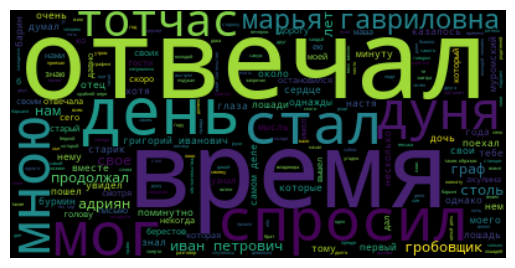

In [101]:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [102]:
fdist_sw.most_common(40)

[('день', 34),
 ('отвечал', 32),
 ('время', 29),
 ('мог', 24),
 ('спросил', 22),
 ('стал', 21),
 ('мною', 21),
 ('несколько', 21),
 ('дуня', 21),
 ('тотчас', 20),
 ('марья', 20),
 ('гавриловна', 20),
 ('петрович', 19),
 ('тому', 19),
 ('гробовщик', 19),
 ('иван', 18),
 ('иванович', 18),
 ('свое', 17),
 ('образом', 17),
 ('лет', 17),
 ('продолжал', 17),
 ('нам', 16),
 ('столь', 16),
 ('друг', 16),
 ('самом', 16),
 ('деле', 16),
 ('граф', 16),
 ('тебе', 16),
 ('адриян', 16),
 ('григорий', 16),
 ('настя', 16),
 ('нем', 15),
 ('отец', 15),
 ('человек', 15),
 ('молодой', 15),
 ('около', 15),
 ('очень', 15),
 ('пошел', 15),
 ('поехал', 15),
 ('сердце', 15)]

In [2]:
from nltk.corpus import stopwords
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['и', 'в','это', 'с','это', 'нею','александр', 'лиза', 'сильвио', 'алексей', 'смотритель','всь','сказал','сказала','своей','своего',
 'сергеевич',
 'владимир',                         
 'пушкин',
 'повести',
 'покойного',
 'ивана',
 'петровича',
 'белкина',
 'гжа',
 'простакова',
 'то',
 'мой',
 'батюшка',
 'он',
 'еще',
 'сызмала',
 'к',
 'историям',
 'охотник',
 'скотинин'])

In [1]:
import nltk
import pymorphy2
import pandas as pd

# Убедитесь, что необходимые ресурсы NLTK загружены
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_ru')

# Открытие файла и чтение текста
with open('/home/jovyan/work/ipynb_dock/data/belkin.txt', "r", encoding="utf-8") as f:
    text = f.read()
# Токенизация текста
tokens = nltk.word_tokenize(text)

# Инициализация морфологического анализатора
morph = pymorphy2.MorphAnalyzer()

# Функция для проверки, является ли слово именем собственным
def is_proper_noun(word):
    parsed_word = morph.parse(word)[0]
    return 'Name' in parsed_word.tag

# Извлечение имен собственных
proper_nouns = [word for word in tokens if is_proper_noun(word)]

# Создание списка часто встречаемых слов
freq_dist = nltk.FreqDist(tokens)
common_words = [word for word, freq in freq_dist.items() if freq > 5]

# Удаление имен собственных из списка часто встречаемых слов
common_words_without_proper_nouns = [word for word in common_words if not is_proper_noun(word)]

# Выровнять длину списков, добавив None
max_len = max(len(proper_nouns), len(common_words_without_proper_nouns))
proper_nouns.extend([None] * (max_len - len(proper_nouns)))
common_words_without_proper_nouns.extend([None] * (max_len - len(common_words_without_proper_nouns)))

# Создание DataFrame из списков proper_nouns и common_words_without_proper_nouns
df = pd.DataFrame({
    'proper_nouns': proper_nouns,
    'common_words_without_proper_nouns': common_words_without_proper_nouns
})

# Печать результата
df.sample(10)

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_ru to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_ru is already up-to-
[nltk_data]       date!


,proper_nouns,common_words_without_proper_nouns
312,Лиза,вдруг
390,Лиза,барышня
384,Иван,старик
336,Лизу,....
9,Петр,по
272,Настя,всегда
2,Митрофан,Белкина
239,напрасну,мысль
281,Анисья,под
426,Алексей,None


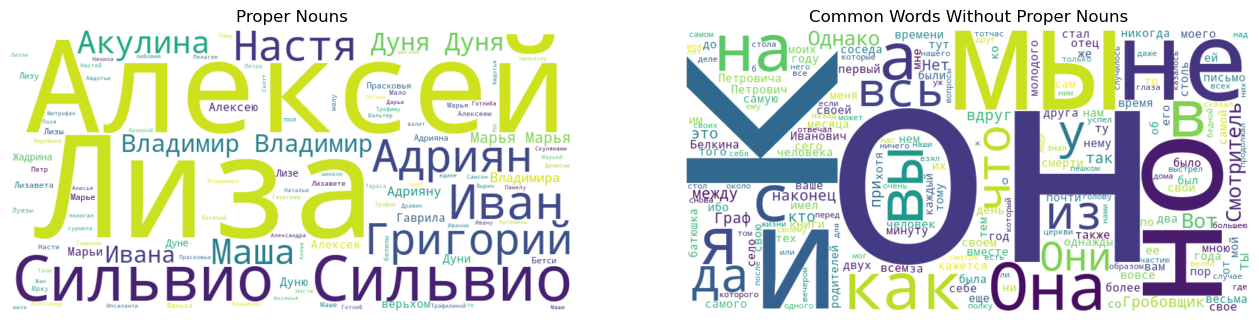

In [4]:
# Создание строк для wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

proper_nouns_text = ' '.join([word for word in proper_nouns if word is not None])
common_words_text = ' '.join([word for word in common_words_without_proper_nouns if word is not None])

# Создание wordcloud для proper nouns
wordcloud_proper_nouns = WordCloud(width=800, height=400, background_color='white').generate(proper_nouns_text)

# Создание wordcloud для common words
wordcloud_common_words = WordCloud(width=800, height=400, background_color='white').generate(common_words_text)

# Визуализация wordclouds
plt.figure(figsize=(16, 8))

# Облако слов для имен собственных
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_proper_nouns, interpolation='bilinear')
plt.title('Proper Nouns')
plt.axis('off')

# Облако слов для частых слов без имен собственных
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_common_words, interpolation='bilinear')
plt.title('Common Words Without Proper Nouns')
plt.axis('off')

# Показать график
plt.show()